<a href="https://colab.research.google.com/github/seungah-lab/Intelligence-powered-epidemiology/blob/main/Week_4_%EC%84%9C%ED%8F%AC%ED%8A%B8%EB%B2%A1%ED%84%B0%EB%A8%B8%EC%8B%A0_ex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 서포트벡터머신 해 보기

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

##### 1. 데이터 로드 (Kaggle dataset: column_2C_weka.csv)

In [5]:
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv')

# 2. 전처리: 시각화를 위해 2개의 수치형 피처 선택 (Age, Na_to_K)
X = df.iloc[:, [0, 4]].values # Age, Na_to_K
y = pd.factorize(df['Drug'])[0] # 'Drug' 열을 수치형으로 변환

##### 2. 데이터 스케일링 (SVM은 거리에 민감하므로 필수적입니다)

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


##### 3. 모델 비교: 선형 SVM vs RBF 커널 SVM

In [8]:
models = (
    SVC(kernel='linear', C=1.0),
    SVC(kernel='rbf', gamma=0.7, C=1.0)
)
models = [clf.fit(X_scaled, y) for clf in models]


##### 4. 시각화 (Decision Boundary)

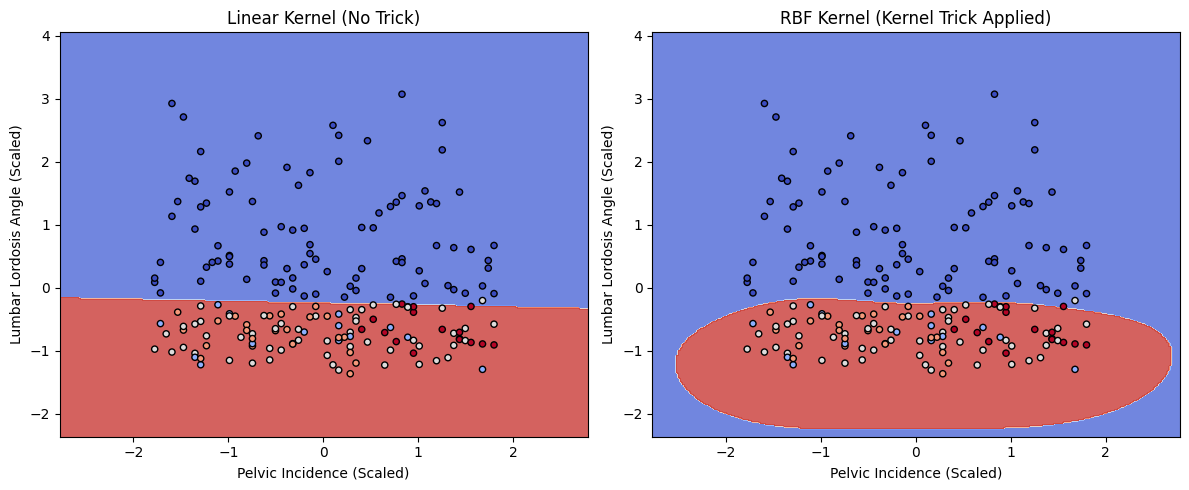

In [9]:
titles = ('Linear Kernel (No Trick)', 'RBF Kernel (Kernel Trick Applied)')
fig, sub = plt.subplots(1, 2, figsize=(12, 5))

# 그리드 생성
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

for clf, title, ax in zip(models, titles, sub.flatten()):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=20)
    ax.set_title(title)
    ax.set_xlabel('Pelvic Incidence (Scaled)')
    ax.set_ylabel('Lumbar Lordosis Angle (Scaled)')

plt.tight_layout()
plt.show()